In [1]:
import eavils_waterfalls as wtrf
import eavils_processing as proc
import eavils_utils
import eavils_prep

import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import sys
import yaml
from copy import deepcopy
import pandas as pd
from astropy.time import Time

## This tutorial walks through how to generate parameters for the EAVILS pol-subtracted metric, and introduces methods for identifying RFI using this metric.

# 0) Initial parameters

We can use the initial_freq_flags paramater for pre-emptively flagging systematics like coarse-band lines for the old MWA correlator, or things like known FM or satellite contaminated channels that we'd like to ignore entirely from the outset.

In [2]:
initial_freq_flags = eavils_utils.coarse_band_flagging() 

We can set our ssins_order to choose the polynomial order of the fit subtracted from SSINS. Default value of 0 for mean-subtraction. Note if this value is changed, you must also overwrite \<prefix\>_SSINS_data.h5 files for it to take effect.

In [3]:
ssins_order=0

Like in SSINS, shape_dict is used to condition which channels we expect RFI to be combined to. In this case, we also add in an additional "subTV" pseudo-channel added as a control "clean channel". 

This subTV channel is quite simply the frequencies below which the digital TV channels live

We only want TV channels, so we remove the 'center_packet_loss' frequency type. We also set the parameters we'd like SSINS to run with.

In [4]:
shape_dict = eavils_utils.get_shape_dict('MWA_EoR_Highband_shape_dict.yml',add_MWA_subTV=True)
del shape_dict['center_packet_loss']
print(shape_dict)

ssins_sig_thresh = {shape: 5 for shape in shape_dict}
ssins_sig_thresh["narrow"] = 5
ssins_sig_thresh["streak"] = 10
del ssins_sig_thresh['subTV']



{'TV6': [174000000.0, 181000000.0], 'TV7': [181000000.0, 188000000.0], 'TV8': [188000000.0, 195000000.0], 'TV9': [195000000.0, 202000000.0], 'subTV': [167075000.0, 174000000.0]}


#### We can also set other SSINS settings here:

In [5]:
tb_aggro=0.4
broadcast_streak=True
time_broadcast=True
freq_broadcast=False

Next, we sort the frequency ranges in our shape_dict according to their minimum frequency. This gets used to organize loops later on in this tutorial. 

We also establish a pol_dict, which connects the labels of polarizations in our dataset with their ordering in pyuvdata arrays.

We also establish a pol_convention_dict, which is used to ensure desired conventions between east/north and x/y are followed. This can be set to None if no translation is required.

Then, we set the frequency channel width in Hz, which is used to correctly save and search for files we use and generate.

In [6]:
sorted_freq_ranges,sorted_freq_mins = proc.freq_range_sort(shape_dict)

pol_dict = {'XX':0,'YY':1,'XY':2,'YX':3}

pol_convention_dict = {'e':'X','n':'Y'} # Can be set to None to bypass

freq_channel_width = 80000 # Channel width in Hz

search_suffix = eavils_prep.freq_channel_width_str(freq_channel_width)+'_cross'

# 1) Initial Processing

#### This section shows how to process raw files (e.g. uvfits files) into data usable for EAVILS. It includes example calls but doesn't actually process data due to raw files being prohibitively large to include on github.

#### The initial processing step reduces the data volume massively by averaging along baselines.

Again, this step will not actually process data without downloading the raw (e.g. uvfits) files that we'd like to process. As it stands it should just return messages that the files already exist, e.g. "OUTPUT CHECKING; found \<file_name\>", followed by "All output files found, skipping. Set clobber=True to overwrite instead.", since we have included the output files from this processing for four observations, listed in example_obs_id_list below.


In [7]:

example_obs_id_list = ['1160938096','1160938216','1160938344','1160938464']

raw_data_folder = '<path/to/raw/data>'
example_output_path = 'testing_tutorial'

for obs_id in example_obs_id_list:

    eavils_prep.prep(
        obs_id = obs_id,
        input_data_folder=raw_data_folder,
        output_path=example_output_path,
        freq_channel_width=freq_channel_width,
        extension='uvfits',
        pol_dict=pol_dict,
        pol_convention_dict=pol_convention_dict,
        ssins_order=ssins_order
    )

OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_EAVILS_data.h5
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_divisor_storage.npy
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_SSINS_data.h5
All output files found, skipping. Set clobber=True to overwrite instead.
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_EAVILS_data.h5
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_divisor_storage.npy
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_SSINS_data.h5
All output files found, skipping. Set clobber=True to overwrite instead.
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_EAVILS_data.h5
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_divisor_storage.npy
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_SSINS_data.h5
All output files found, skipping. Set clobber=True to overw

#### Once we have created these initial EAVILS files, along with their companion SSINS files, we can generate long plots, that show how RFI evolves over time. This is incredibly useful for screening the data for extended "wobbly" DTV events in EAVILS, which we refer to as COWs (Contained Observable Wobbles).

#### First, we set a directory with input list files. List files are text lists of observations tags that are used to divide the observations into per-night and (if necessary) per-sky-field chunks.

In [8]:
list_file_directory = 'example_obs_lists'

#### Generate plots like the below for at least one night of data. Identify any sections of data that have COWs as seen in the XX (ee) polarization here.

Note that we have included a "restricted_list" that only plots the observations we have data for here. In general, this can be removed or set to None for plotting an entire list.

In [9]:
restricted_list = ['1160938096', '1160938216', '1160938344', '1160938464']
# restricted_list can be set to None for plotting a full list
list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')
proc.create_plots(
    list_file = list_file,
    input_directory = 'testing_tutorial/h5_files/',
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    prelim_mode=True,
    output_directory = 'example_plots',
    display_pointing_changes=False,
    restricted_list = restricted_list,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast
)

"proc.create_plots(\n    list_file = list_file,\n    input_directory = 'testing_tutorial/h5_files/',\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = search_suffix,\n    prelim_mode=True,\n    output_directory = 'example_plots',\n    display_pointing_changes=False,\n    restricted_list = restricted_list,\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh,\n    tb_aggro=tb_aggro,\n    broadcast_streak=broadcast_streak,\n    time_broadcast=time_broadcast,\n    freq_broadcast=freq_broadcast\n)"

#### For MWA data, we need to make sure which observations come from which sky field is clear, so that we can carry that data through. Here, we build "sky_field_list_association", a dictionary which associates each list's name with a sky field (in this case the EOR-0 and EOR-1 fields).

In [10]:
sky_field_list = ['EOR0','EOR1']

all_lists = []
for file in os.listdir(list_file_directory):
    if file.endswith(".txt"):
        all_lists.append(file)
all_lists = sorted(all_lists)

list_titles = [file.split('.')[0] for file in all_lists ]

sky_field_list_association = {}
for list_title in list_titles:
    for sky_field in sky_field_list:
        if sky_field in list_title:
            sky_field_list_association[list_title] = sky_field
print(sky_field_list_association)

{'10-15-2016-EOR0': 'EOR0', '10-15-2016-EOR1': 'EOR1', '10-17-2016-EOR0': 'EOR0', '10-17-2016-EOR1': 'EOR1', '10-19-2016-EOR0': 'EOR0', '10-19-2016-EOR1': 'EOR1', '10-21-2016-EOR0': 'EOR0', '10-21-2016-EOR1': 'EOR1', '10-22-2016-EOR0': 'EOR0', '10-22-2016-EOR1': 'EOR1', '10-26-2016-EOR0': 'EOR0', '10-26-2016-EOR1': 'EOR1', '10-28-2016-EOR0': 'EOR0', '10-28-2016-EOR1': 'EOR1', '10-30-2016-EOR0': 'EOR0', '10-30-2016-EOR1': 'EOR1', '11-12-2016-EOR0': 'EOR0', '11-17-2016-EOR0': 'EOR0', '11-19-2016-EOR0': 'EOR0', '11-21-2016-EOR0': 'EOR0', '12-15-2016-EOR0': 'EOR0'}


#### We need to set the time dimensions of the averaging we want to do for the next step. A time_dim of 8 on 2 second integrations corresponds with a 16 second time-scale for averaging, which is typical for the variations we see in COWs. However, other choices can be made here for more rapidly or more slowly changing RFI.

Note: When the number of times doesn't divide evenly by the dimensions, the remaining data will be averaged into the maximum possible chunk size.


In [11]:
time_dim = 8

#### The h5 file input directory should contain should be set to the h5_files subdirectory of the output_path of our call to eavils_prep.prep above. Since we didn't process a full suite of data in the previous step, we use a fake directory here, but if we were executing this code on live data, we would put:
h5_input_directory = 'testing_tutorial/h5_files'

#### Instead, for the tutorial we put:

In [12]:
h5_input_directory = '<path/to/h5/input/directory>'

We include only the four example per-observation EAVILS files plotted above on the github due to size constraints. 

Nonetheless, we show how you can process a full set of per-observation EAVILS files in the following call to proc.process_data below. In reality this step has already been run and has generated output files contained here. In order to run this step from scratch, we require the per-observation EAVILS files that would be processed by eavils_prep.prep when real raw files are used. 

In the tutorial, proc.process should just return messages like:

"Tutorial mode active. Suppressing some warnings & errors

__ observations processed. __ observations had existing output files"




#### Ensure that tutorial_mode_bool gets set to False when processing new data!

In [13]:


tutorial_mode_bool = True # Suppresses errors to demonstrate code in the tutorial with underlying data missing

if tutorial_mode_bool:
    allowed_missing_fraction = 1 

    clobber = False
    
    metafits_folder = None 
else:
    allowed_missing_fraction = 0.1 # The fraction of input files that can be missing before erroring. 

    clobber = False # Clobber will overwrite existing data, set it to true when reprocessing data that has already been written to output files.
    
    metafits_folder = '<path/to/metafits>' # When processing data for the MWA, make sure to set metafits_folder below to the correct folder containing metafits files, in order to correctly extract pointing information.

In [14]:

for list_file in all_lists:
    
    list_title=list_file.split('.txt')[0]
    list_file = f'{list_file_directory}/{list_file}'
    proc.process_data(list_file=list_file,
        input_directory=h5_input_directory,
        output_directory='testing_tutorial/',
        time_dim=time_dim,
        pol_dict=pol_dict,
        shape_dict=shape_dict,
        initial_freq_flags=initial_freq_flags,
        suffix_add=search_suffix,
        metafits_folder=metafits_folder,
        pre_flag_on_SSINS_masks=True,
        clobber=clobber, 
        allowed_missing_fraction=allowed_missing_fraction,
        ssins_sig_thresh=ssins_sig_thresh,
        tb_aggro=tb_aggro,
        broadcast_streak=broadcast_streak,
        time_broadcast=time_broadcast,
        freq_broadcast=freq_broadcast,
        tutorial_mode_bool=tutorial_mode_bool
    )
    

Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 85 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 92 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 84 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 91 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 78 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 97 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 78 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 97 observations had existing output files


# 2) Turning processed EAVILS data into pol-subtracted data

#### With our processed data in hand, we can generate pol-subtracted metric values.

In [15]:
processed_data_directory = 'testing_tutorial/'

#### Here we establish the order in which polarizations should be subtracted, in this case our call says we should subtract XX - YY.

In [16]:

pol_subtraction_order = ('XX','YY')

#### With this step we read processed data in, generating numpy arrays in a dictionary called array_dict, as well as some other helpful data we'll use later on, like which sky-field corresponds to each observation (sky_field_dict), which source list the observation was in (obs_list_dict), and which pointing our observations correspond to (combined_pointing_info_dict; outputs None when add_pointing_dict set to False)

In [17]:


array_dict, sky_field_dict,obs_list_dict,combined_pointing_info_dict = proc.create_data_arrays(
    processed_data_directory = processed_data_directory,
    list_titles=list_titles,
    shape_dict=shape_dict,
    sky_field_list_association=sky_field_list_association,
    pol_subtraction_order=pol_subtraction_order,
    pol_dict=pol_dict,
    time_dim=time_dim,
    add_pointing_dict=True
)

creating data arrays
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0


#### The array_dict has the following keys

In [18]:
array_dict.keys()

dict_keys(['variance', 'reshaped_SSINS_mask', 'pol_sub', 'lst', 'time'])

#### The variance, reshaped_SSINS_mask and pol_sub arrays in array_dict have dimensions of (no. of time chunks, no. of freq. ranges, no. of polarizations)


In [19]:
example_obs_id = list(array_dict['variance'].keys())[0]

array_dict['variance'][example_obs_id].shape

(7, 5, 4)

#### For pol_sub data, only the first polarization index is actually utilized, corresponding to the polarization subtraction order set in pol_subtraction_order above. The rest of the array should be filled with nans. An example:

In [20]:
array_dict['pol_sub'][example_obs_id][:,:,0]

array([[ 0.05615998,  0.0928946 , -0.35124217, -0.0067279 , -0.64829063],
       [-0.11692081, -0.07927599,  0.22747222,  0.18104656,  0.18815547],
       [-0.24318871,  0.10428962, -0.21316501,  0.10913981, -0.18444659],
       [ 0.25654796,  0.0880907 ,  0.01463962, -0.13376831,  0.08338078],
       [-0.00910449, -0.27129613,  0.015238  , -0.61316288,  0.00165958],
       [-0.06842512,  0.23551702, -0.15318538, -0.11064019,  0.65326084],
       [ 0.08220859, -0.38725986,  0.27701844, -0.0199449 ,  0.28314896]])

In [21]:
array_dict['pol_sub'][example_obs_id][:,:,1]

array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan]])

#### Next, we put our data into a dataframe for easy referencing, including some important metadata for each entry. This returns a pandas dataframe which collects the important data for each measurement into a single pandas dataframe. In other words, for each frequency and time block, there is a row with all the input data.

In [22]:

datafr = proc.create_data_frame(
    pol_dict=pol_dict,
    shape_dict=shape_dict,
    array_dict=array_dict,
    sky_field_dict=sky_field_dict,
    obs_list_dict=obs_list_dict,
    pointing_info_dict=combined_pointing_info_dict
)

In [23]:
datafr

,obs_tag,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pointing_flagged,obs_list,lst,variance_XX,variance_YY,variance_XY,variance_YX,freq_range
0,1160570624,EOR0,0,-3,0.056160,False,False,10-15-2016-EOR0,5.795401,0.930381,0.874221,1.165624,0.805463,subTV
1,1160570624,EOR0,1,-3,-0.116921,False,False,10-15-2016-EOR0,5.796568,0.833849,0.950770,0.945195,0.821406,subTV
2,1160570624,EOR0,2,-3,-0.243189,False,False,10-15-2016-EOR0,5.797735,0.796453,1.039642,0.869831,0.716382,subTV
3,1160570624,EOR0,3,-3,0.256548,False,False,10-15-2016-EOR0,5.798902,0.952697,0.696149,0.715717,0.611442,subTV
4,1160570624,EOR0,4,-3,-0.009104,False,False,10-15-2016-EOR0,5.800068,0.998381,1.007485,0.792033,1.004230,subTV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,0.031423,False,False,12-15-2016-EOR0,0.265812,0.652026,0.620603,0.454005,0.835356,TV9
58971,1165836936,EOR0,3,2,0.599237,True,False,12-15-2016-EOR0,0.266979,1.880602,1.281364,1.193661,1.063842,TV9
58972,1165836936,EOR0,4,2,-0.559859,True,False,12-15-2016-EOR0,0.268145,1.839106,2.398965,1.362883,1.465797,TV9
58973,1165836936,EOR0,5,2,-0.630309,True,False,12-15-2016-EOR0,0.269312,1.467617,2.097926,1.850622,1.513904,TV9


### Here we establish a threshold for flagging
#### This will be used in the following steps. We base this threshold on some simple assumptions on what we want our false positive rate to be per pointing, and how many data points we can expect per pointing. This is a flexible threshold

#### We choose a threshold with the following formula, where isf is the inverse survival function for the normal distribution:
isf(False positive rate/(num_tv_channels * time chunks per observation * approximate number of observations per pointing))

isf(.001 / ( 5 x 7 x 15 ))

In [24]:
scipy.stats.norm.isf(.001/(5*7*15)) 

4.621512496696125

In [25]:
threshold = 4.62 #Rounding to three decimal places

# 3) Estimating standard deviation for pol-subtracted metric

### Its really important to get this step right to be accurate with our pol-subtracted metric. We go through the process of finding clean data to use as an initial guess for the standard deviation, and then how to get a better estimate

#### We will want to create plots for a complete night using steps like the following. We have commented this call out here, since we don't have all the necessary files to create the file, and instead display an already-created example file.

In [26]:
''' 
input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR0.txt')
proc.create_plots(
    list_file = input_list_file,
    input_directory = h5_input_directory,
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    prelim_mode=True,
    output_directory = 'example_plots/',
    display_pointing_changes=True,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast,
    split_on_pointings=True,
    pointing_info_dict=combined_pointing_info_dict
)
'''

"input_list_file = list_file_directory+'/10-19-2016-EOR0.txt'\n\nproc.create_plots(\n    list_file = input_list_file,\n    input_directory = h5_input_directory,\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = search_suffix,\n    prelim_mode=True,\n    output_directory = 'example_plots/',\n    display_pointing_changes=True,\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh,\n    tb_aggro=tb_aggro,\n    broadcast_streak=broadcast_streak,\n    time_broadcast=time_broadcast,\n    freq_broadcast=freq_broadcast,\n    split_on_pointings=True,\n    pointing_info_dict=combined_pointing_info_dict\n)\n"

In [27]:
'''
input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt'

proc.create_plots(
    list_file = input_list_file,
    input_directory = h5_input_directory,
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    prelim_mode=True,
    output_directory = 'example_plots/',
    display_pointing_changes=True,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast,
    split_on_pointings=True,
    pointing_info_dict=combined_pointing_info_dict
)
'''

"input_list_file = list_file_directory+'/10-19-2016-EOR1.txt'\n\nproc.create_plots(\n    list_file = input_list_file,\n    input_directory = h5_input_directory,\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = search_suffix,\n    prelim_mode=True,\n    output_directory = 'example_plots/',\n    display_pointing_changes=True,\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh,\n    tb_aggro=tb_aggro,\n    broadcast_streak=broadcast_streak,\n    time_broadcast=time_broadcast,\n    freq_broadcast=freq_broadcast,\n    split_on_pointings=True,\n    pointing_info_dict=combined_pointing_info_dict\n)\n"

In [28]:
from IPython.display import Image, display
for pointing in range(-3,3):
    display(Image(filename=f'example_plots/10-19-2016-EOR0__ptng_{pointing}_EAVILS.jpg'))



"from IPython.display import Image, display\nfor pointing in range(-3,3):\n    display(Image(filename=f'example_plots/10-19-2016-EOR0__ptng_{pointing}_EAVILS.jpg'))"

In [29]:
from IPython.display import Image, display
for pointing in range(-3,4):
    display(Image(filename=f'example_plots/10-19-2016-EOR1__ptng_{pointing}_EAVILS.jpg'))



"from IPython.display import Image, display\nfor pointing in range(-3,4):\n    display(Image(filename=f'example_plots/10-19-2016-EOR1__ptng_{pointing}_EAVILS.jpg'))"

We can see that, for this night, in EOR-0, we have only a few observations that appear to have EAVILS plots with noticeable RFI, 1160919672 (pointing -1) and then later 1160925160 and 1160925288 (pointing 2). In EOR-1, COWs begin appearing in observation 1160937120 (pointing 0), and continue on and off through the rest of the plots. While we could just mark out only the observations where we see RFI that SSINS doesn't catch, we will instead give them a wide berth and mark out all the observations in the pointings where we see RFI.

We will pre-filter any SSINS-flagged data, so no need to avoid data with RFI that SSINS detects.

The key idea here is that we want to give our initial estimate good data, so even in a telescope without pointings, it's recommended to start with blocking out some good data far away from any visible RFI in EAVILS. While the more data the better, around an hour of good data like we have here should be enough to establish our initial estimate for the pol-sub metric's standard deviation. This data does not have to be drwan from the same night.


The following list of tuples marks out the starting and ending observations we'd like to mark as good. To include only our good EOR-0 pointings, we add (1160915280, 1160919184) for pointings -3 and -2, and (1160921384, 1160924672) to include pointings 0 and 1. For including only EOR-1 pointings -3 through -1, we add  (1160930288, 1160935288). 

In [30]:
initial_good_tups = [('1160915280', '1160919184'), ('1160921384', '1160924672'), ('1160930288', '1160935288')]

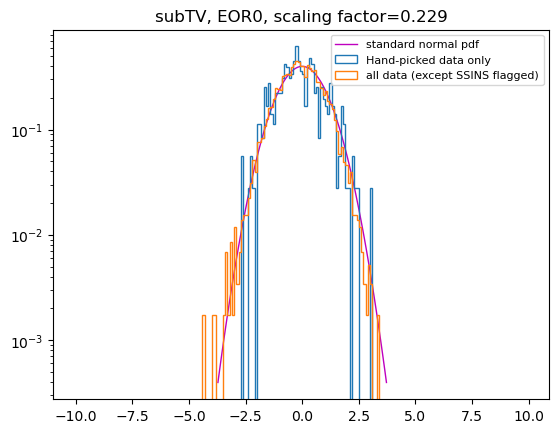

subTV 0.22918347057807112


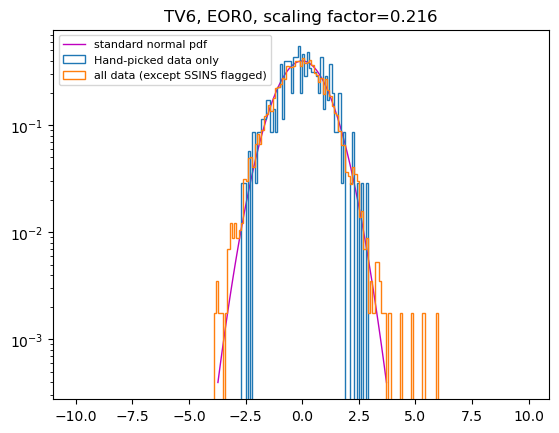

TV6 0.21567721163142153


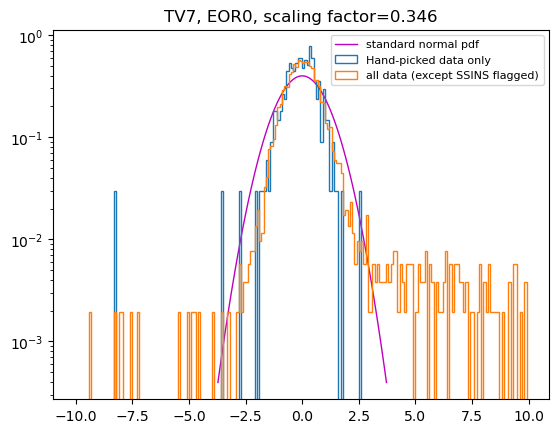

TV7 0.3463312611066634


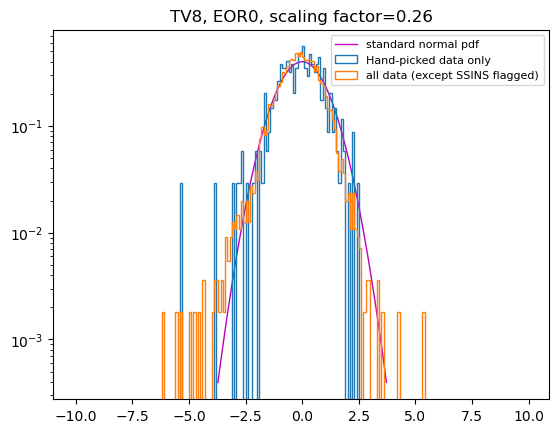

TV8 0.26002327002011016


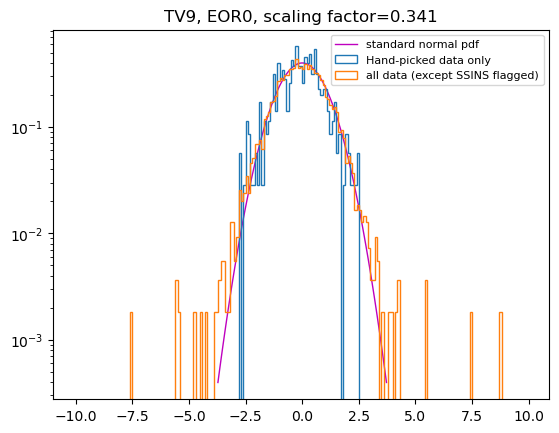

TV9 0.3412062051219938


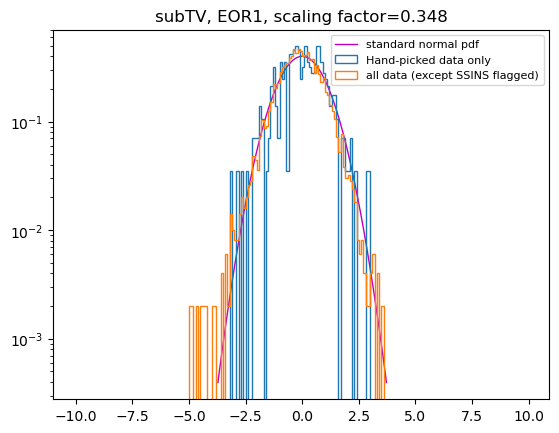

subTV 0.3481783995232274


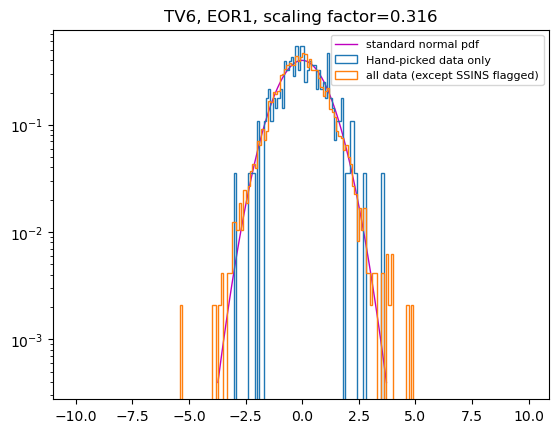

TV6 0.31609464151951544


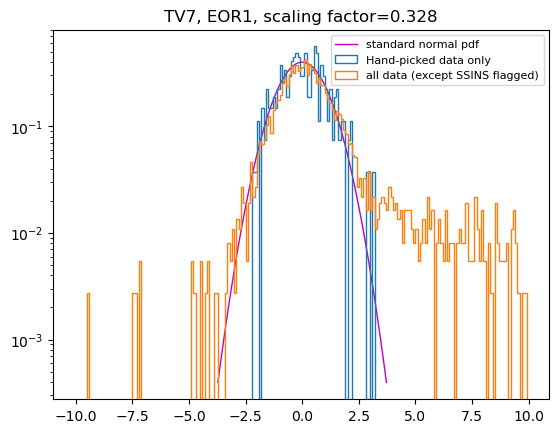

TV7 0.32826831666232814


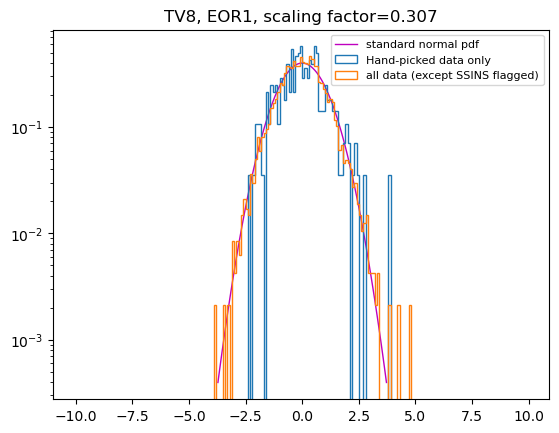

TV8 0.307463486916874


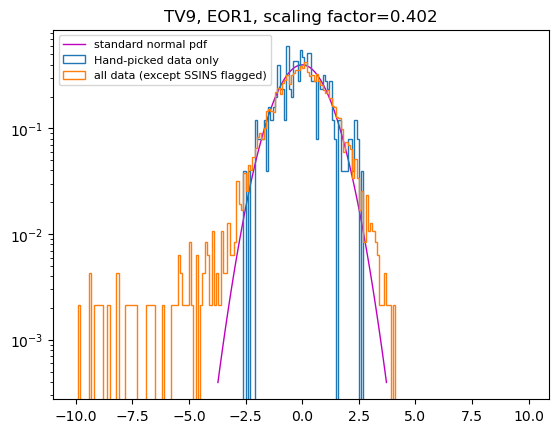

TV9 0.4021797472978533


In [31]:
initial_estimated_pol_sub_stdv= {sky_field:{} for sky_field in sky_field_list}



for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        
        pol_sub_series_clean = []

        for tup in initial_good_tups:

            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & obs_tag>=\'{tup[0]}\' & obs_tag<=\'{tup[1]}\''
            pol_sub_series_clean += list(datafr.query(query_string_clean)['pol_sub'])

        pol_sub_series_clean=np.array(pol_sub_series_clean)

        scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
        
        initial_estimated_pol_sub_stdv[sky_field][freq_range] = scaling

        
        pol_sub_series = datafr.query(f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\' & SSINS_flagged=={False}')['pol_sub']

       

        plt.yscale('log')
        x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                    scipy.stats.norm.ppf(0.9999,scale=1), 100)
        plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                'm-', lw=1, alpha=1, label='standard normal pdf')
        plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='Hand-picked data only')
        
        plt.hist((pol_sub_series)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')


        plt.title(f'{freq_range}, {sky_field}, scaling factor={np.round(scaling,3)}')
        plt.legend( prop={'size': 8})
        plt.show()
        
        print(freq_range,scaling)
    

#### Above, we have plotted our hand-chosen "clean" data in blue and all data for that frequency range and sky field in orange, with both histograms rescaled using the estimated standard deviation from the clean data, and a standard normal distribution is shown in purple. Note that the TV7 estimate for EOR-0 looks a bit off, we have too many bad data points despite our hand-picked data. This is ok within reason, since our initial guess will be refined in the next step. We get the following initial estimates for the standard deviation for each field/channel combo:

In [32]:
initial_estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.22918347057807112,
  'TV6': 0.21567721163142153,
  'TV7': 0.3463312611066634,
  'TV8': 0.26002327002011016,
  'TV9': 0.3412062051219938},
 'EOR1': {'subTV': 0.3481783995232274,
  'TV6': 0.31609464151951544,
  'TV7': 0.32826831666232814,
  'TV8': 0.307463486916874,
  'TV9': 0.4021797472978533}}

Note that the TV9 channel tends to have a higher standard deviation than the other channels. This is expected, because fewer frequencies are present in that channel within the frequency range the MWA is observing at for this dataset. Thus, fewer values go into the calculation of the variance for each measurement, and so the distribution of variances is wider, and thus the difference between variances between polarizations tends to be higher!

With our initial estimate of the standard deviation for the pol-subtracted metric in mind, we'd like to incorporate more data into our estimate. We thus use our initial estimate as a basis for identifying any pointing that has at least one measurement cross our predetermined threshold in a given frequency range. This is a conservative way to make sure our data is likely to be contamination free. We then get a new estimate of our standard deviation for each pol-subtracted distribution, check against the threshold again, and repeat until our estimates don't change.

iterations: 0
EOR0 subTV estimate shifted by -0.007330865958219718
EOR0 TV6 estimate shifted by 0.008272600188646145
EOR0 TV7 estimate shifted by -0.10304971749552486
EOR0 TV8 estimate shifted by -0.023509921256436445
EOR0 TV9 estimate shifted by 0.018676937693372087
EOR1 subTV estimate shifted by -0.022359536080810594
EOR1 TV6 estimate shifted by 0.0005518708059149002
EOR1 TV7 estimate shifted by 0.0024941884343245846
EOR1 TV8 estimate shifted by -0.010140468062565633
EOR1 TV9 estimate shifted by 0.048892453276207226
{'EOR0': {'subTV': 0.2218526046198514, 'TV6': 0.22394981182006768, 'TV7': 0.24328154361113855, 'TV8': 0.23651334876367372, 'TV9': 0.3598831428153659}, 'EOR1': {'subTV': 0.3258188634424168, 'TV6': 0.31664651232543034, 'TV7': 0.3307625050966527, 'TV8': 0.29732301885430834, 'TV9': 0.4510722005740605}}
iterations: 1
EOR0 subTV estimate shifted by 0.0
EOR0 TV6 estimate shifted by 0.0
EOR0 TV7 estimate shifted by -0.0005833975351771659
EOR0 TV8 estimate shifted by -0.0033924360

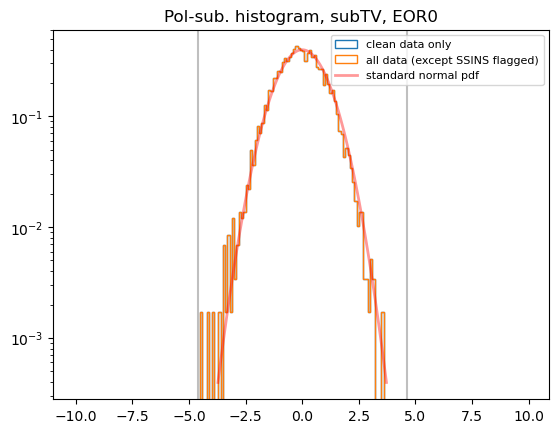

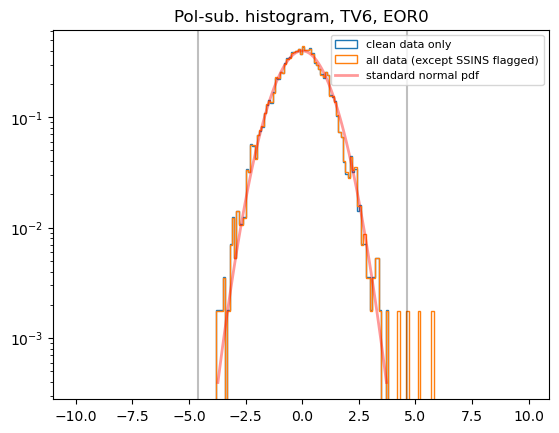

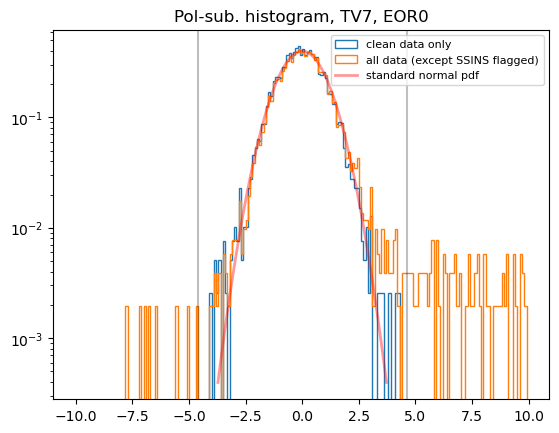

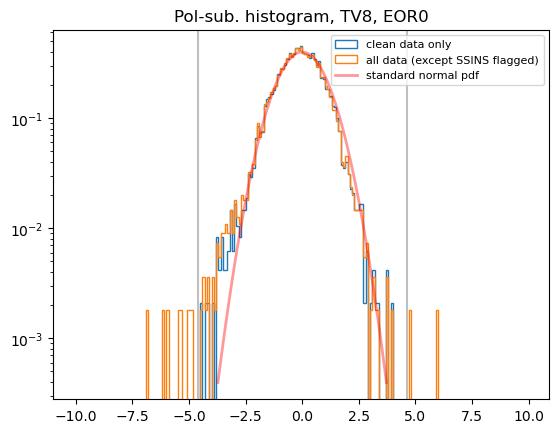

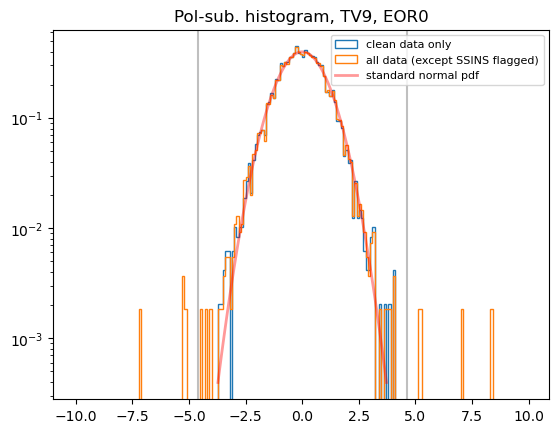

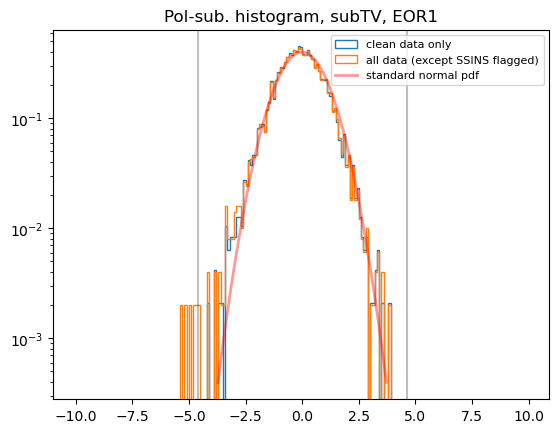

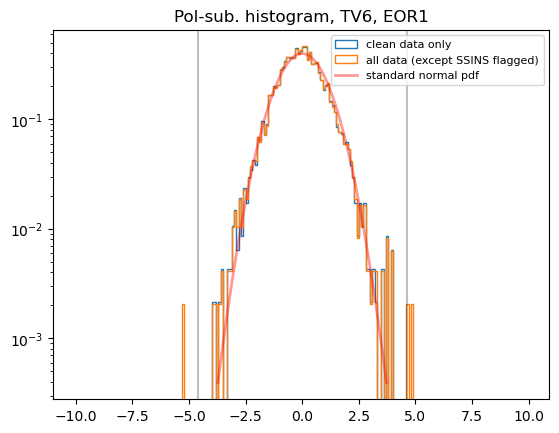

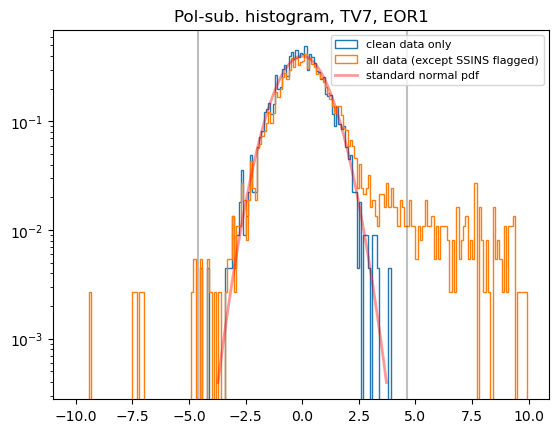

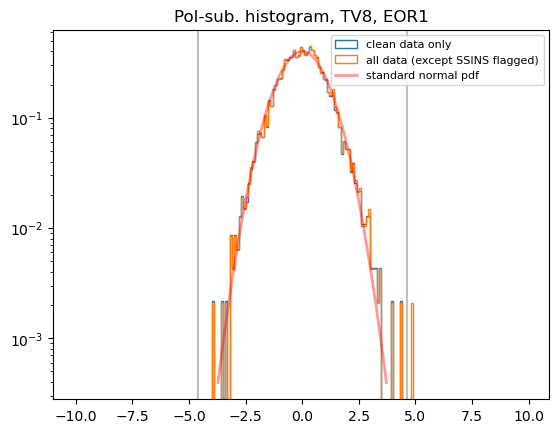

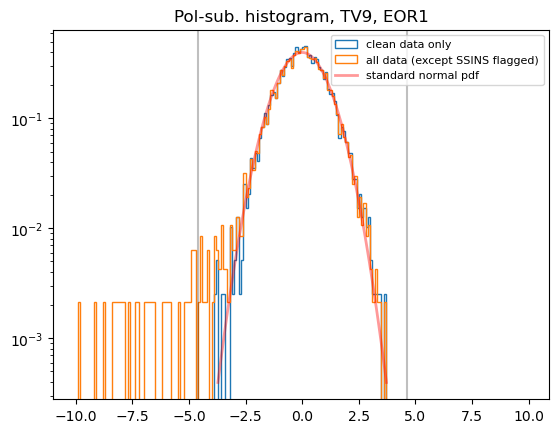

In [33]:
iteration_count=0

datafr['pointing_flagged'] = False #This should already be true, but ensures it's the case

estimated_pol_sub_stdv = deepcopy(initial_estimated_pol_sub_stdv)
while True:
    print('iterations:',iteration_count)
    prev_estimated_pol_sub_stdv = deepcopy(estimated_pol_sub_stdv)
    
    for obs_list in np.unique(datafr.obs_list):
        
        sky_field = sky_field_list_association[obs_list]

        for pointing in np.unique(datafr.pointing):
            for freq_range in sorted_freq_ranges:
                query_string = f'sky_field==\'{sky_field}\' & obs_list==\'{obs_list}\' & pointing=={pointing} & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                sub_series = datafr.query(query_string)['pol_sub']
                estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
                outliers = np.abs(sub_series)>(estimated_stdv*threshold)
    
                if np.sum(outliers)>0:
                    flag_pointing=True
                else:
                    flag_pointing=False
                if flag_pointing:
                    flagged_indices = datafr.query(query_string).index
                    datafr.loc[flagged_indices,'pointing_flagged'] = True
    
    
    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
            pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
    
            scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
            
            estimated_pol_sub_stdv[sky_field][freq_range] = scaling

    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            print(sky_field,freq_range,'estimate shifted by', estimated_pol_sub_stdv[sky_field][freq_range] - prev_estimated_pol_sub_stdv[sky_field][freq_range])
    print(estimated_pol_sub_stdv) 
    if estimated_pol_sub_stdv==prev_estimated_pol_sub_stdv:    
        for sky_field in sky_field_list:
            for freq_range in sorted_freq_ranges:
                query_string_all = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                pol_sub_series_all = datafr.query(query_string_all)['pol_sub']

                query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
                pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
                plt.yscale('log')
                
                scaling = estimated_pol_sub_stdv[sky_field][freq_range]

                plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='clean data only')
                plt.hist((pol_sub_series_all)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')
                plt.vlines([-threshold,threshold],ymin=0,ymax=1,color='black',alpha=.25)
                
                x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                            scipy.stats.norm.ppf(0.9999,scale=1), 100)
                plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                        'r-', lw=2, alpha=0.4, label='standard normal pdf')
                plt.title(f'Pol-sub. histogram, {freq_range}, {sky_field}')
                plt.legend( prop={'size': 8})
                plt.show()
        break
    iteration_count+=1
           

#### We get the following estimate for standard deviations. We save it out to a yaml file.

In [34]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.2218526046198514,
  'TV6': 0.22394981182006768,
  'TV7': 0.24269814607596138,
  'TV8': 0.2331209127385393,
  'TV9': 0.3598831428153659},
 'EOR1': {'subTV': 0.3258188634424168,
  'TV6': 0.31664651232543034,
  'TV7': 0.3307625050966527,
  'TV8': 0.29732301885430834,
  'TV9': 0.4510722005740605}}

In [35]:
#Yaml is unhappy with numpy floats, so we fix this here
for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'w') as file:
    for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
            
        
    yaml.safe_dump(estimated_pol_sub_stdv, file, default_flow_style=False, sort_keys=False) 

# 4) Flagging data

#### We load in this estimated standard deviation for the pol-subtracted metric generated above here.

In [36]:
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'r') as file:
    estimated_pol_sub_stdv = yaml.safe_load(file) # Use safe_load for security

#### We add this estimated standard deviation to our dataframe and generate flags in this next step.

In [37]:
datafr = proc.add_pol_sub_stdv(datafr,estimated_pol_sub_stdv,threshold)

In [38]:
datafr

,obs_tag,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pointing_flagged,obs_list,lst,variance_XX,variance_YY,variance_XY,variance_YX,freq_range,pol_sub_stdv,pol_sub_flagged
0,1160570624,EOR0,0,-3,0.056160,False,False,10-15-2016-EOR0,5.795401,0.930381,0.874221,1.165624,0.805463,subTV,0.221853,False
1,1160570624,EOR0,1,-3,-0.116921,False,False,10-15-2016-EOR0,5.796568,0.833849,0.950770,0.945195,0.821406,subTV,0.221853,False
2,1160570624,EOR0,2,-3,-0.243189,False,False,10-15-2016-EOR0,5.797735,0.796453,1.039642,0.869831,0.716382,subTV,0.221853,False
3,1160570624,EOR0,3,-3,0.256548,False,False,10-15-2016-EOR0,5.798902,0.952697,0.696149,0.715717,0.611442,subTV,0.221853,False
4,1160570624,EOR0,4,-3,-0.009104,False,False,10-15-2016-EOR0,5.800068,0.998381,1.007485,0.792033,1.004230,subTV,0.221853,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,0.031423,False,False,12-15-2016-EOR0,0.265812,0.652026,0.620603,0.454005,0.835356,TV9,0.359883,False
58971,1165836936,EOR0,3,2,0.599237,True,False,12-15-2016-EOR0,0.266979,1.880602,1.281364,1.193661,1.063842,TV9,0.359883,False
58972,1165836936,EOR0,4,2,-0.559859,True,False,12-15-2016-EOR0,0.268145,1.839106,2.398965,1.362883,1.465797,TV9,0.359883,False
58973,1165836936,EOR0,5,2,-0.630309,True,False,12-15-2016-EOR0,0.269312,1.467617,2.097926,1.850622,1.513904,TV9,0.359883,False


#### To make a long plot including the pol-subtracted metric, ensure prelim_mode is set to False. Also ensure the following additional arguments have been supplied:

In [39]:

input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')
restricted_list = ['1160938096', '1160938216', '1160938344', '1160938464']

proc.create_plots(
    list_file = input_list_file,
    input_directory = 'testing_tutorial/h5_files/',
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    output_directory = 'example_plots/',
    display_pointing_changes=False,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast,
    restricted_list = restricted_list,
    # Arguments required for getting pol-sub plots:
    prelim_mode=False,
    threshold=threshold,
    estimated_pol_sub_stdv=estimated_pol_sub_stdv,
    array_dict=array_dict,
    sky_field_dict=sky_field_dict,
    time_dim=time_dim
    
)


"input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')\nrestricted_list = ['1160938096', '1160938216', '1160938344', '1160938464']\nprelim_mode = False\nproc.create_plots(\n    list_file = input_list_file,\n    input_directory = 'testing_tutorial/h5_files/',\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = search_suffix,\n    prelim_mode=prelim_mode,\n    output_directory = 'example_plots/',\n    display_pointing_changes=False,\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh,\n    tb_aggro=tb_aggro,\n    broadcast_streak=broadcast_streak,\n    time_broadcast=time_broadcast,\n    freq_broadcast=freq_broadcast,\n    restricted_list = restricted_list,\n    threshold=threshold,\n    estimated_pol_sub_stdv=estimated_pol_sub_stdv,\n    array_dict=array_dict,\n    sky_field_dict=sky_field_dict,\n    time_dim=time_dim\n    \n)"

#### You can also give more detailed plotting instructions, such as including variance plots like we do here, by supplying  an argument to plot_instructions. The nomenclature is:

('\<quantity to plot\>','\<polarization\>','\<plot style\>', '\<plot width\>'

We also supply an argument to output_tagging to alter the filename and avoid overwriting the plot we just made.

In [40]:

input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')
restricted_list = ['1160938096', '1160938216', '1160938344', '1160938464']
prelim_mode = False
plot_instructions = [                      
                        ('variance', 'XX', 'raster', 1),
                        ('SSINS', 'XX', 'raster', 1),
                        ('EAVILS', 'XX', 'raster', 1),
                        ('pol_sub', 'XX-YY', 'line_plot', 2),
                        ('SSINS_flags', 'XX', 'raster', 1),
                        ('EAVILS', 'YY', 'raster', 1),
                        ('SSINS', 'YY', 'raster', 1),
                        ('variance', 'YY', 'raster', 1)
                     ]
output_tagging = '_+variance'
proc.create_plots(
    list_file = input_list_file,
    input_directory = 'testing_tutorial/h5_files/',
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    prelim_mode=prelim_mode,
    output_directory = 'example_plots/',
    display_pointing_changes=False,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast,
    restricted_list = restricted_list,
    # Arguments required for getting pol-sub plots:
    prelim_mode=False,
    threshold=threshold,
    estimated_pol_sub_stdv=estimated_pol_sub_stdv,
    array_dict=array_dict,
    sky_field_dict=sky_field_dict,
    time_dim=time_dim,
    # Additional arguments for altering plots
    plot_instructions =  plot_instructions,
    output_tagging = output_tagging
)

"input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')\nrestricted_list = ['1160938096', '1160938216', '1160938344', '1160938464']\nprelim_mode = False\nplot_instructions = [                      \n                        ('variance', 'XX', 'raster', 1),\n                        ('SSINS', 'XX', 'raster', 1),\n                        ('EAVILS', 'XX', 'raster', 1),\n                        ('pol_sub', 'XX-YY', 'line_plot', 2),\n                        ('SSINS_flags', 'XX', 'raster', 1),\n                        ('EAVILS', 'YY', 'raster', 1),\n                        ('SSINS', 'YY', 'raster', 1),\n                        ('variance', 'YY', 'raster', 1)\n                     ]\noutput_tagging = '_+variance'\nproc.create_plots(\n    list_file = input_list_file,\n    input_directory = 'testing_tutorial/h5_files/',\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = search_suffix,\n    prelim_mode=prelim_mode,\n    output_directory = 'example_plots/',

#### To plot a full list of data, run the following without triple quotes:

In [ ]:
'''
input_list_file = os.path.join(list_file_directory,'10-19-2016-EOR1.txt')
prelim_mode = False

proc.create_plots(
    list_file = input_list_file,
    input_directory = h5_input_directory,
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = search_suffix,
    prelim_mode = prelim_mode,
    output_directory = 'example_plots/',
    display_pointing_changes=True,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    tb_aggro=tb_aggro,
    broadcast_streak=broadcast_streak,
    time_broadcast=time_broadcast,
    freq_broadcast=freq_broadcast,
    split_on_pointings=True,
    pointing_info_dict=combined_pointing_info_dict,
    # Arguments required for getting pol-sub plots:
    prelim_mode=False,
    threshold=threshold,
    estimated_pol_sub_stdv=estimated_pol_sub_stdv,
    array_dict=array_dict,
    sky_field_dict=sky_field_dict,
    time_dim=time_dim
)
'''

In [41]:
import eavils_waterfalls as wtrf


We can make an EAVILS plot for an individual observations as follows:

No output path set, outputs will not be saved


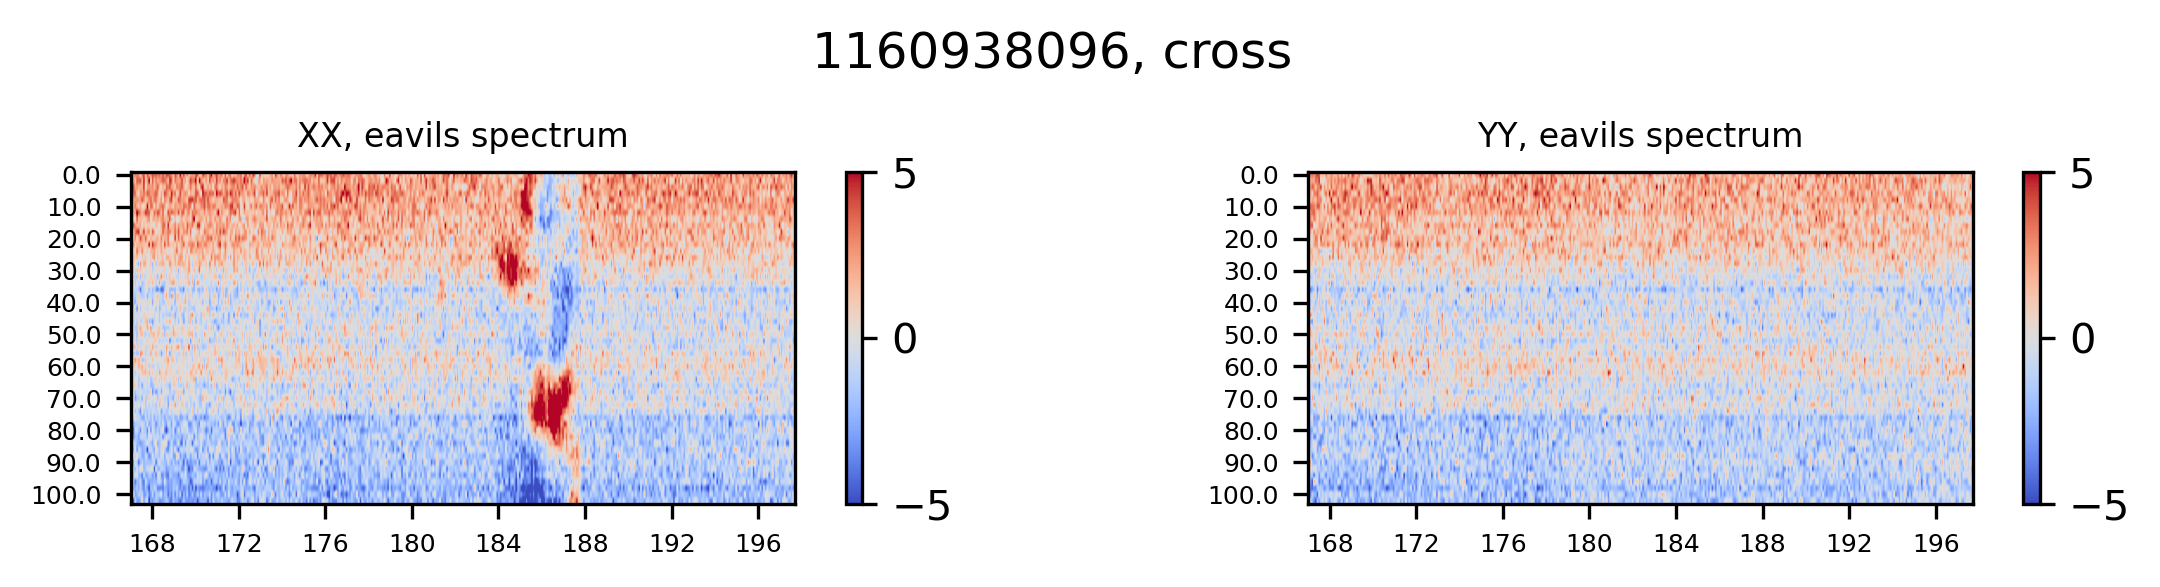

In [42]:


obs_tag = '1160938096'

eavils = wtrf.EAVILS(f'testing_tutorial/h5_files/{obs_tag}_80khz_cross_EAVILS_data.h5')
divisor_storage_array = np.load(f'testing_tutorial/h5_files/{obs_tag}_80khz_cross_divisor_storage.npy')

eavils.build_div_and_spectrum(divisor_storage_array)
wtrf.plot_maker(eavils=eavils,pols=['XX','YY'],name_prefix=obs_tag,show_plots=True,eavils_spectrum_only=True)


We can "expand" the flags to the shape of this waterfall as follows:

In [43]:

expanded_flag_array = proc.flag_expander(
    datafr = datafr,
    obs_tag = obs_tag,
    time_dim = time_dim, 
    Ntimes_total = eavils.Ntimes, 
    shape_dict = shape_dict, 
    freq_array = eavils.freq_array,
    Npols=eavils.Npols)    

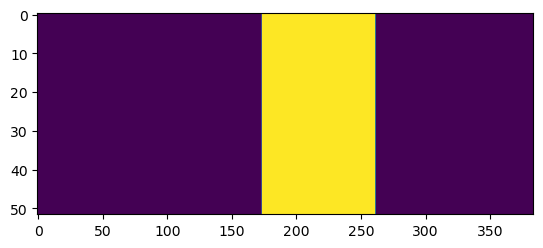

In [44]:
plt.imshow(expanded_flag_array[:,:,0],aspect=3)